# Comparison of EEG Channel Selection Methods
This notebook visualizes the 5-fold cross-validation performance comparison between using Full Channel EEG and Selected Channel EEG (Fz, Cz, POz with Delta+Alpha bands) for predicting trial scores. It automatically parses the latest evaluation metrics from the `training_logs` directory.

Selected Channel CSV: training_logs/5_kfold_tfpower_trial_score_20260409_172650.csv
Full Channel CSV: training_logs/5_kfold_trial_score_log_fr_20260326_031611.csv



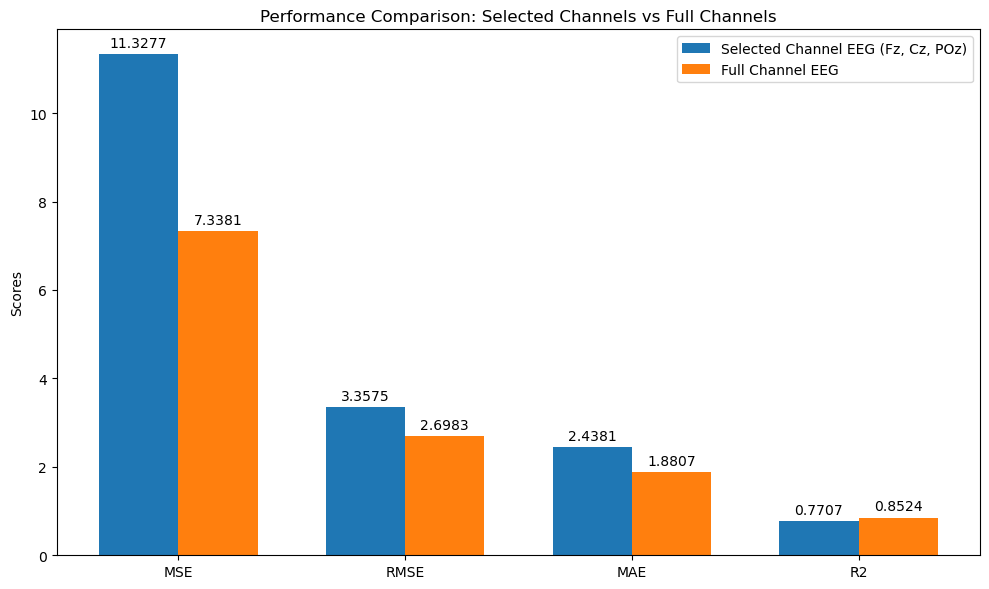

In [2]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np

def extract_metrics(csv_path):
    metrics = {}
    try:
        with open(csv_path, 'r') as f:
            lines = f.readlines()
            
        start_idx = -1
        for i, line in enumerate(lines):
            if line.startswith('Metric,'):
                start_idx = i
                break
                
        if start_idx == -1:
            return None
            
        for line in lines[start_idx+1:]:
            parts = line.strip().split(',')
            if len(parts) >= 4 and parts[0] in ['MSE', 'RMSE', 'MAE', 'R2']:
                metrics[parts[0]] = float(parts[3])
    except Exception as e:
        print(f"Error reading {csv_path}: {e}")
    return metrics

def get_latest_csv(log_dir, prefix):
    files = glob.glob(os.path.join(log_dir, prefix))
    if not files:
        return None
    return max(files, key=os.path.getmtime)

log_dir = 'training_logs'
selected_csv = get_latest_csv(log_dir, '5_kfold_tfpower_trial_score_*.csv')
full_csv = get_latest_csv(log_dir, '5_kfold_trial_score_log_fr_*.csv')

print(f"Selected Channel CSV: {selected_csv}")
print(f"Full Channel CSV: {full_csv}\n")

selected_metrics_dict = extract_metrics(selected_csv) if selected_csv else None
full_metrics_dict = extract_metrics(full_csv) if full_csv else None

metrics = ['MSE', 'RMSE', 'MAE', 'R2']

if selected_metrics_dict and full_metrics_dict:
    selected_channel_scores = [selected_metrics_dict.get(m, 0) for m in metrics]
    full_channel_scores = [full_metrics_dict.get(m, 0) for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, selected_channel_scores, width, label='Selected Channel EEG (Fz, Cz, POz)', color='#1f77b4')
    rects2 = ax.bar(x + width/2, full_channel_scores, width, label='Full Channel EEG', color='#ff7f0e')

    ax.set_ylabel('Scores')
    ax.set_title('Performance Comparison: Selected Channels vs Full Channels')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    fig.tight_layout()
    plt.show()
else:
    print("Could not find or parse metrics from one or both CSV files.")
